# 20a — 17g model EXACTLY on the REAL data (series-20 baseline transfer test)

**Series 20 — real-data agentic optimization.** Start from 17g, the best-performing model so far
(all 14 *synthetic* experiments recovered to their true values: mu RMSE 3.7%, gamma RMSE 4.3%),
and apply it **unchanged** to the **real** measured FWHM data. This is the transfer baseline the
rest of the series learns from.

**20a change (the ONLY change vs 17g):** the target is no longer generated by our own simulator at
the true values — it is the **real** per-experiment target (FWHM + fit-error columns, 15-series
load & filter: drop NaNs/non-positive, keep `err/fwhm < 10`).

**Frozen from 17g:** `SIGMA_REF=10`, z-form gamma-score (`GAMMA_SCALE=True`, `H_REF=1`),
`LR_MU=15` (linear decay), `LR_GAMMA=0.5` (annealed), `CLIP=10`, `LAMBDA_MEAN=0`, `H_S_MIN=0.05`,
`SEED=42`, init at 0.5x truth.

**Series-20 budget:** `N_RUNS=100`, `N_ITER=30` (vs 17g's 200/200).

**Hypothesis / prediction (falsifiable):** because the model's NLL optimum and the truth coincide on
synthetic data but NOT on real data (19b: NLL(mu) minimizes at mu/mu_true ~ 0.3-0.5), 20a should
reproduce the **mu attractor** at mid/high transmission and the **1nW low-T gamma deficit** (FM#6).
Prediction: gamma_rec/gamma_true < 0.6 at 1nW T05/T10 and mu_rec/mu_true ~ 0.4-0.6 at T>=20.

**Goal (series-20, transmission-graded):** accuracy should *climb with transmission* —
|dmu|/sigma, |dgamma|/sigma <= ~2 at high T, loose at low T. See SERIES_STATE.md.


## Figure panel (fixed across series 20)
1. **FIG 1** phase-space paths (mu, gamma) per experiment — start/end/truth.
2. **FIG 2** normalized trajectories mu/mu_true, gamma/gamma_true (-> 1.0).
3. **FIG 3** NLL per step (dead kernel / bad basin detector).
4. **FIG 4** ★ accuracy vs transmission (mu and gamma ratios; goal: climb to 1.0 with T).
5. **FIG 5** ★ coverage vs transmission |dmu|/sigmamu, |dgamma|/sigmagamma (1-sigma/2-sigma bands).
6. **FIG 6** real-vs-sim distribution match (FWHM + sigma_fit KDE per experiment) — FM#6.
7. **FIG 7** final results table + MSE/STE.
8. **FIG 8** NLL(mu) slice at gamma_true — the mu-attractor diagnostic.
9. **FIG 9** sigma-channel autopsy (median fit error, real vs sim, vs transmission) — FM#8.
10. **FIG 10** Fisher ellipses in (mu, gamma) at the fitted point.

Convention: figures render **inline only** (no savefig); the notebook is executed **in place**.


In [1]:
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
# ============================================================
# EXPERIMENTS — true values from Gregor's fits (identical to 17f/16-series) + real data file
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393, sigma_prop=2.576, lam=2.232, gamma_true=8.5, n_target=61, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans05.txt'),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372, sigma_prop=3.445, lam=2.122, gamma_true=8.5, n_target=358, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans10.txt'),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316, sigma_prop=4.141, lam=2.286, gamma_true=8.5, n_target=1138, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans20.txt'),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405, sigma_prop=7.198, lam=2.351, gamma_true=8.5, n_target=2428, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans40.txt'),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374, sigma_prop=9.851, lam=2.593, gamma_true=8.5, n_target=2424, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans60.txt'),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365, sigma_prop=12.627, lam=2.758, gamma_true=8.5, n_target=2487, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans80.txt'),
    dict(name='1nW Trans100',  power='1nW', mu_true=70.817, sigma_prop=17.221, lam=2.636, gamma_true=8.5, n_target=2455, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans100.txt'),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204, sigma_prop=3.724, lam=2.186, gamma_true=14.1, n_target=252, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans05.txt'),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476, sigma_prop=5.639, lam=2.158, gamma_true=14.1, n_target=1572, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans10.txt'),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279, sigma_prop=8.319, lam=2.264, gamma_true=14.1, n_target=2171, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans20.txt'),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892, sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans40.txt'),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95, lam=2.741, gamma_true=14.1, n_target=2541, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans60.txt'),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans80.txt'),
    dict(name='3nW Trans100',  power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans100.txt'),
]

# ---- QUICK TEST: uncomment one of these slices ----
# EXPERIMENTS = EXPERIMENTS[:3]                                        # first 3
# EXPERIMENTS = [e for e in EXPERIMENTS if e['name'] in
#                ('1nW Trans80', '3nW Trans80', '3nW Trans100')]      # the hard ones

print(f'{len(EXPERIMENTS)} experiments configured')


14 experiments configured


In [3]:
# ============================================================
# SERIES 20 — 20a CONFIG: 17g model EXACTLY, real targets, 100 runs x 30 iters
# ============================================================
N_RUNS   = 100        # 20-series budget (17g: 200)
N_ITER   = 30         # 20-series budget (17g: 200)
LR_MU    = 15.0       # REINFORCE mu learning rate (17g: linear decay to ~0)
LR_GAMMA = 0.5        # gamma learning rate (17g: annealed x(1 - 0.5 t/N))
SIGMA_REF = 10.0      # 17g: mu-score normalization (scale-invariant step)
GAMMA_SCALE = True    # 20a/17g: z-form gamma-score (bandwidth-normalized, fixed reference)
H_REF = 1.0           # fixed reference bandwidth for the z-form gamma-score
CLIP     = 10.0       # gradient clipping
SEED     = 42         # per-step noise seed base

LAMBDA_MEAN = 0.0     # mean-matching weight (0.0 = disabled, as 17g)
H_S_MIN     = 0.05    # absolute floor for the sigma-kernel bandwidth (MHz)

# ---- FISHER / CRB (15-series protocol; gives sigma_mu, sigma_gamma, coverage) ----
M_FINAL = 500
FISHER_SEEDS = 1
FISHER_BASE_SEED = 7000

# ---- SMOKE: NB_SMOKE=1 -> fast 3-experiment subset (validates machinery + all figures) ----
SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    N_RUNS, N_ITER, M_FINAL = 10, 5, 50
    EXPERIMENTS = EXPERIMENTS[:3]
    print('*** SMOKE RUN ***')

# ============================================================
# PARALLELISM (L2 + L3)
# ============================================================
N_CPUS = os.cpu_count() or 4
N_EXP_PARALLEL = 1    # experiments at once (L3)
N_WORKERS = 4         # run-loop workers per experiment (L2)
if N_EXP_PARALLEL * N_WORKERS > N_CPUS:
    N_WORKERS = max(1, N_CPUS // N_EXP_PARALLEL)

print(f'config: N_RUNS={N_RUNS}, N_ITER={N_ITER}, LAMBDA_MEAN={LAMBDA_MEAN}, H_S_MIN={H_S_MIN}')
print(f'fisher: M_FINAL={M_FINAL}, FISHER_SEEDS={FISHER_SEEDS}')
print(f'parallelism: {N_EXP_PARALLEL} exp(s) x {N_WORKERS} workers on {N_CPUS} CPUs')


config: N_RUNS=100, N_ITER=30, LAMBDA_MEAN=0.0, H_S_MIN=0.05
fisher: M_FINAL=500, FISHER_SEEDS=1
parallelism: 1 exp(s) x 4 workers on 4 CPUs


In [4]:
# ============================================================
# Fixed helpers (identical to the 16-series) + parallel machinery
# ============================================================
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)

def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')

def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop):
    # 2D KDE negative log-likelihood + per-data-point scores (as 16-series).
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        # 17g/18c: z-form γ-score — ONE power of bandwidth (unitless distances), fixed reference.
        # Removes the 1/H^2 amplification that saturates the clip and causes γ jumps.
        dlogG = ((d_f * sim_df[None, :]) / h_f + (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    nll_val = -logp.mean()
    return s_mu, s_gamma, nll_val, w

# ---- fork pool: one process per worker, each single-threaded (L2) ----
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker():
    torch.set_num_threads(1)

def _parallel_map(pool, tasks):
    return list(pool.map(_run_one, tasks, chunksize=8))

print('helpers ready')

helpers ready


In [5]:
# ============================================================
# One experiment: joint μ + γ optimization (KDE likelihood + 17f improvements, REAL targets)
# ============================================================
def run_experiment(exp):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true

    # ---- REAL target data (15-series load & filter) ----
    d = np.genfromtxt(exp['data_file'])
    fwhm_mhz = d[:, 0] * 1000.0
    err_mhz = d[:, 1] * 1000.0
    ok = ~np.isnan(fwhm_mhz) & ~np.isnan(err_mhz) & (fwhm_mhz > 0)
    filt = ok & (err_mhz / fwhm_mhz < 10.0)
    target_f = torch.tensor(fwhm_mhz[filt], dtype=torch.float32)
    target_s = torch.tensor(err_mhz[filt], dtype=torch.float32)
    n_target = len(target_f)
    SCOTT_EXP = n_target ** (-1.0 / 6.0)
    H_F = float(target_f.std()) * SCOTT_EXP
    H_S = max(float(target_s.std()) * SCOTT_EXP, H_S_MIN)

    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'),
              initializer=_init_worker) as pool:
        mu_val = float(mu_init)
        gamma_val = float(gamma_init)
        history = []
        t0 = time.time()

        for step in range(N_ITER):
            rng2 = np.random.default_rng(SEED + step)
            tasks, ns = [], []
            for _ in range(N_RUNS):
                u, b, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng2)
                tasks.append((gamma_val, u.numpy(), b.numpy()))
                ns.append(n)
            res = _parallel_map(pool, tasks)
            fwhms = [r[0] for r in res]
            sigmas = [r[1] for r in res]
            dfs = [r[2] for r in res]
            dsigmas = [r[3] for r in res]

            ft = torch.tensor(fwhms, dtype=torch.float32)
            si_t = torch.tensor(sigmas, dtype=torch.float32)
            nt = torch.tensor(ns, dtype=torch.float32)
            dg_t = torch.tensor(dfs, dtype=torch.float32)
            ds_t = torch.tensor(dsigmas, dtype=torch.float32)

            s_mu, s_gamma, nll_val, w = kde_scores(
                ft, si_t, nt, dg_t, ds_t, target_f, target_s, H_F, H_S, mu_val, sigma_prop)

            # ---- μ: REINFORCE (17f: scale-invariant step) ----
            B = w.mean(dim=0)
            score = (nt - mu_val) / SIGMA_REF ** 2
            grad_mu = float(max(min(-(B - B.mean()) @ score, CLIP), -CLIP))

            # ---- γ: KDE channel ----
            grad_gamma = float(max(min(-s_gamma.mean(), CLIP), -CLIP))

            # ---- mean-matching anchor (disabled: LAMBDA_MEAN = 0) ----
            mean_sim = float(ft.mean())
            mean_tgt = float(target_f.mean())
            mean_loss = abs(mean_sim - mean_tgt)
            if LAMBDA_MEAN > 0:
                d_mean_dgamma = float(dg_t.mean())
                grad_gamma_mean = -math.copysign(1.0, mean_sim - mean_tgt) * d_mean_dgamma
                grad_gamma = float(max(min(grad_gamma + LAMBDA_MEAN * grad_gamma_mean, CLIP), -CLIP))

            # ---- updates (17f) ----
            lr_mu_decay = LR_MU * (1.0 - step / N_ITER)   # no decay floor
            mu_val -= lr_mu_decay * grad_mu
            mu_val = max(1.0, min(200.0, mu_val))
            gamma_val -= LR_GAMMA * (1.0 - 0.5 * step / N_ITER) * grad_gamma   # γ anneal
            gamma_val = max(0.1, min(100.0, gamma_val))

            history.append(dict(step=step, mu=mu_val, gamma=gamma_val, nll=float(nll_val),
                                grad_mu=grad_mu, grad_gamma=grad_gamma, mean_loss=mean_loss,
                                mean_n=float(nt.mean())))

    return dict(exp=exp['name'], power=exp['power'],
                mu_true=mu_true, gamma_true=gamma_true, sigma_prop=sigma_prop, lam=lam,
                n_target=n_target,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'],
                nll_final=history[-1]['nll'], mean_loss_final=history[-1]['mean_loss'],
                history=history, H_F=H_F, H_S=H_S,
                target_f=target_f, target_s=target_s,
                t_elapsed=time.time() - t0)

print('run_experiment ready (REAL data)')


run_experiment ready (REAL data)


In [6]:
# ============================================================
# RUN ALL 14 (L3: N_EXP_PARALLEL experiments at once)
# ============================================================
t_all = time.time()
results = []

if N_EXP_PARALLEL <= 1:
    for exp in EXPERIMENTS:
        print(f"Running {exp['name']:>12} ...", end=' ', flush=True)
        r = run_experiment(exp)
        results.append(r)
        print(f"μ {r['mu_true']:.2f} -> {r['mu_final']:.2f} | γ {r['gamma_true']:.1f} -> {r['gamma_final']:.2f} | "
              f"NLL {r['nll_final']:.2f} | {r['t_elapsed']/60:.1f} min", flush=True)
else:
    with _PPE(max_workers=N_EXP_PARALLEL, mp_context=_mp.get_context('fork'),
              initializer=_init_worker) as pool:
        for exp, r in zip(EXPERIMENTS, pool.map(run_experiment, EXPERIMENTS)):
            results.append(r)
            print(f"{exp['name']:>12}: μ {r['mu_true']:.2f} -> {r['mu_final']:.2f} | "
                  f"γ {r['gamma_true']:.1f} -> {r['gamma_final']:.2f} | NLL {r['nll_final']:.2f} | "
                  f"{r['t_elapsed']/60:.1f} min", flush=True)

print(f'\nTotal: {(time.time()-t_all)/60:.1f} min')

Running  1nW Trans05 ... 

μ 9.39 -> 4.99 | γ 8.5 -> 14.23 | NLL 1.34 | 1.0 min


Running  1nW Trans10 ... 

μ 12.37 -> 6.81 | γ 8.5 -> 4.75 | NLL 1.20 | 0.9 min


Running  1nW Trans20 ... 

...

Running  3nW Trans80 ... 

μ 137.54 -> 58.47 | γ 14.1 -> 13.89 | NLL 3.00 | 0.9 min


Running 3nW Trans100 ... 

μ 175.71 -> 72.35 | γ 14.1 -> 13.59 | NLL 2.73 | 1.0 min



Total: 12.8 min


In [7]:
# ============================================================
# FISHER / CRB at the fitted point for all experiments (15-series protocol)
# J = sum_i s(x_i) s(x_i)^T / n_target, s = [s_mu, s_gamma] from kde_scores
# (s_mu uses sigma_prop^2 -> identical definition to 15-series).
# Also stores the fitted-point sim draws in FIT for FIGS 6/9.
# ============================================================
Tmap = {e['name']: int(e['name'].split('Trans')[1]) for e in EXPERIMENTS}
fisher_rows = []
FIT = {}
with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'),
          initializer=_init_worker) as pool:
    for r in results:
        mu_f = r['mu_final']; gamma_f = r['gamma_final']
        sp = r['sigma_prop']; lam = r['lam']
        J_list = []; keep = None
        for seed in range(FISHER_SEEDS):
            rng = np.random.default_rng(FISHER_BASE_SEED + seed)
            tasks, ns = [], []
            for _ in range(M_FINAL):
                u, b_, n = draw_fixed_noise(mu_f, sp, lam, rng)
                tasks.append((gamma_f, u.numpy(), b_.numpy())); ns.append(n)
            res = _parallel_map(pool, tasks)
            ft = torch.tensor([x[0] for x in res], dtype=torch.float32)
            si_t = torch.tensor([x[1] for x in res], dtype=torch.float32)
            nt = torch.tensor(ns, dtype=torch.float32)
            dg_t = torch.tensor([x[2] for x in res], dtype=torch.float32)
            ds_t = torch.tensor([x[3] for x in res], dtype=torch.float32)
            s_mu, s_gamma, _, _ = kde_scores(ft, si_t, nt, dg_t, ds_t,
                                             r['target_f'], r['target_s'], r['H_F'], r['H_S'], mu_f, sp)
            s = torch.stack([s_mu, s_gamma], dim=1)
            J_list.append(s.T @ s / len(r['target_f']))
            keep = (ft, si_t, nt)
        J = torch.stack(J_list).mean(dim=0)
        Jinv = torch.linalg.inv(J + 1e-8 * torch.eye(2))
        std_mu = math.sqrt(Jinv[0, 0]); std_gamma = math.sqrt(Jinv[1, 1])
        corr = Jinv[0, 1] / math.sqrt(Jinv[0, 0] * Jinv[1, 1])
        fisher_rows.append(dict(exp=r['exp'], T=Tmap[r['exp']], mu_f=mu_f, gamma_f=gamma_f,
                                mu_true=r['mu_true'], gamma_true=r['gamma_true'], n_target=r['n_target'],
                                std_mu=std_mu, std_gamma=std_gamma, corr=corr, Jinv=Jinv))
        FIT[r['exp']] = keep
        print(f"{r['exp']:<12} mu_hat={mu_f:8.2f} (true {r['mu_true']:7.2f}, {abs(mu_f-r['mu_true'])/std_mu:4.2f}s) | "
              f"g_hat={gamma_f:7.2f} (true {r['gamma_true']:5.1f}, {abs(gamma_f-r['gamma_true'])/std_gamma:4.2f}s) | "
              f"s_mu={std_mu:7.2f} s_g={std_gamma:5.2f} corr={corr:+.2f}")

print()
print(f"{'exp':<12} {'N_tgt':>5} {'mu_fin':>8} {'s_mu':>7} {'dmu/s':>6} | {'g_fin':>7} {'s_g':>6} {'dg/s':>6} {'corr':>6}")
print('-' * 76)
for f in fisher_rows:
    print(f"{f['exp']:<12} {f['n_target']:>5} {f['mu_f']:>8.2f} {f['std_mu']:>7.2f} "
          f"{(f['mu_f']-f['mu_true'])/f['std_mu']:>+6.2f} | {f['gamma_f']:>7.2f} {f['std_gamma']:>6.2f} "
          f"{(f['gamma_f']-f['gamma_true'])/f['std_gamma']:>+6.2f} {f['corr']:>+6.2f}")


1nW Trans05  mu_hat=    4.99 (true    9.39, 0.05s) | g_hat=  14.23 (true   8.5, 611902459746267.88s) | s_mu=  85.93 s_g= 0.00 corr=-0.15


1nW Trans10  mu_hat=    6.81 (true   12.37, 0.31s) | g_hat=   4.75 (true   8.5, 178.65s) | s_mu=  18.03 s_g= 0.02 corr=-0.28


1nW Trans20  mu_hat=    8.69 (true   17.32, 0.95s) | g_hat=   7.56 (true   8.5, 2.25s) | s_mu=   9.07 s_g= 0.42 corr=-0.01


1nW Trans40  mu_hat=   18.69 (true   38.41, 1.23s) | g_hat=   6.73 (true   8.5, 2.33s) | s_mu=  15.99 s_g= 0.76 corr=+0.09


1nW Trans60  mu_hat=   28.78 (true   61.37, 1.95s) | g_hat=   6.98 (true   8.5, 1.64s) | s_mu=  16.69 s_g= 0.93 corr=-0.17


...

3nW Trans20  mu_hat=   15.98 (true   34.28, 0.94s) | g_hat=  13.31 (true  14.1, 0.94s) | s_mu=  19.52 s_g= 0.84 corr=+0.19


3nW Trans40  mu_hat=   39.89 (true   84.89, 0.84s) | g_hat=  11.88 (true  14.1, 3.16s) | s_mu=  53.64 s_g= 0.70 corr=+0.12


3nW Trans60  mu_hat=   43.47 (true  103.20, 1.07s) | g_hat=  12.31 (true  14.1, 1.98s) | s_mu=  55.96 s_g= 0.91 corr=+0.26


3nW Trans80  mu_hat=   58.47 (true  137.54, 1.05s) | g_hat=  13.89 (true  14.1, 0.28s) | s_mu=  75.26 s_g= 0.75 corr=+0.27


3nW Trans100 mu_hat=   72.35 (true  175.71, 1.12s) | g_hat=  13.59 (true  14.1, 0.56s) | s_mu=  92.47 s_g= 0.91 corr=+0.29

exp          N_tgt   mu_fin    s_mu  dmu/s |   g_fin    s_g   dg/s   corr
----------------------------------------------------------------------------
1nW Trans05     61     4.99   85.93  -0.05 |   14.23   0.00 +611902459746267.88  -0.15
1nW Trans10    358     6.81   18.03  -0.31 |    4.75   0.02 -178.65  -0.28
1nW Trans20   1138     8.69    9.07  -0.95 |    7.56   0.42  -2.25  -0.01
1nW Trans40   2428    18.69   15.99  -1.23 |    6.73   0.76  -2.33  +0.09
1nW Trans60   2424    28.78   16.69  -1.95 |    6.98   0.93  -1.64  -0.17
1nW Trans80   2487    37.91   24.98  -1.66 |    7.57   1.02  -0.91  -0.08
1nW Trans100  2455    34.33   36.44  -1.00 |    7.90   0.94  -0.64  -0.01
3nW Trans05    252     6.95   14.04  -0.45 |    5.38   0.48 -18.15  +0.51
3nW Trans10   1572    11.66   11.75  -1.09 |    5.01   0.27 -33.58  +0.08
3nW Trans20   2171    15.98   19.52  -0.94 | 

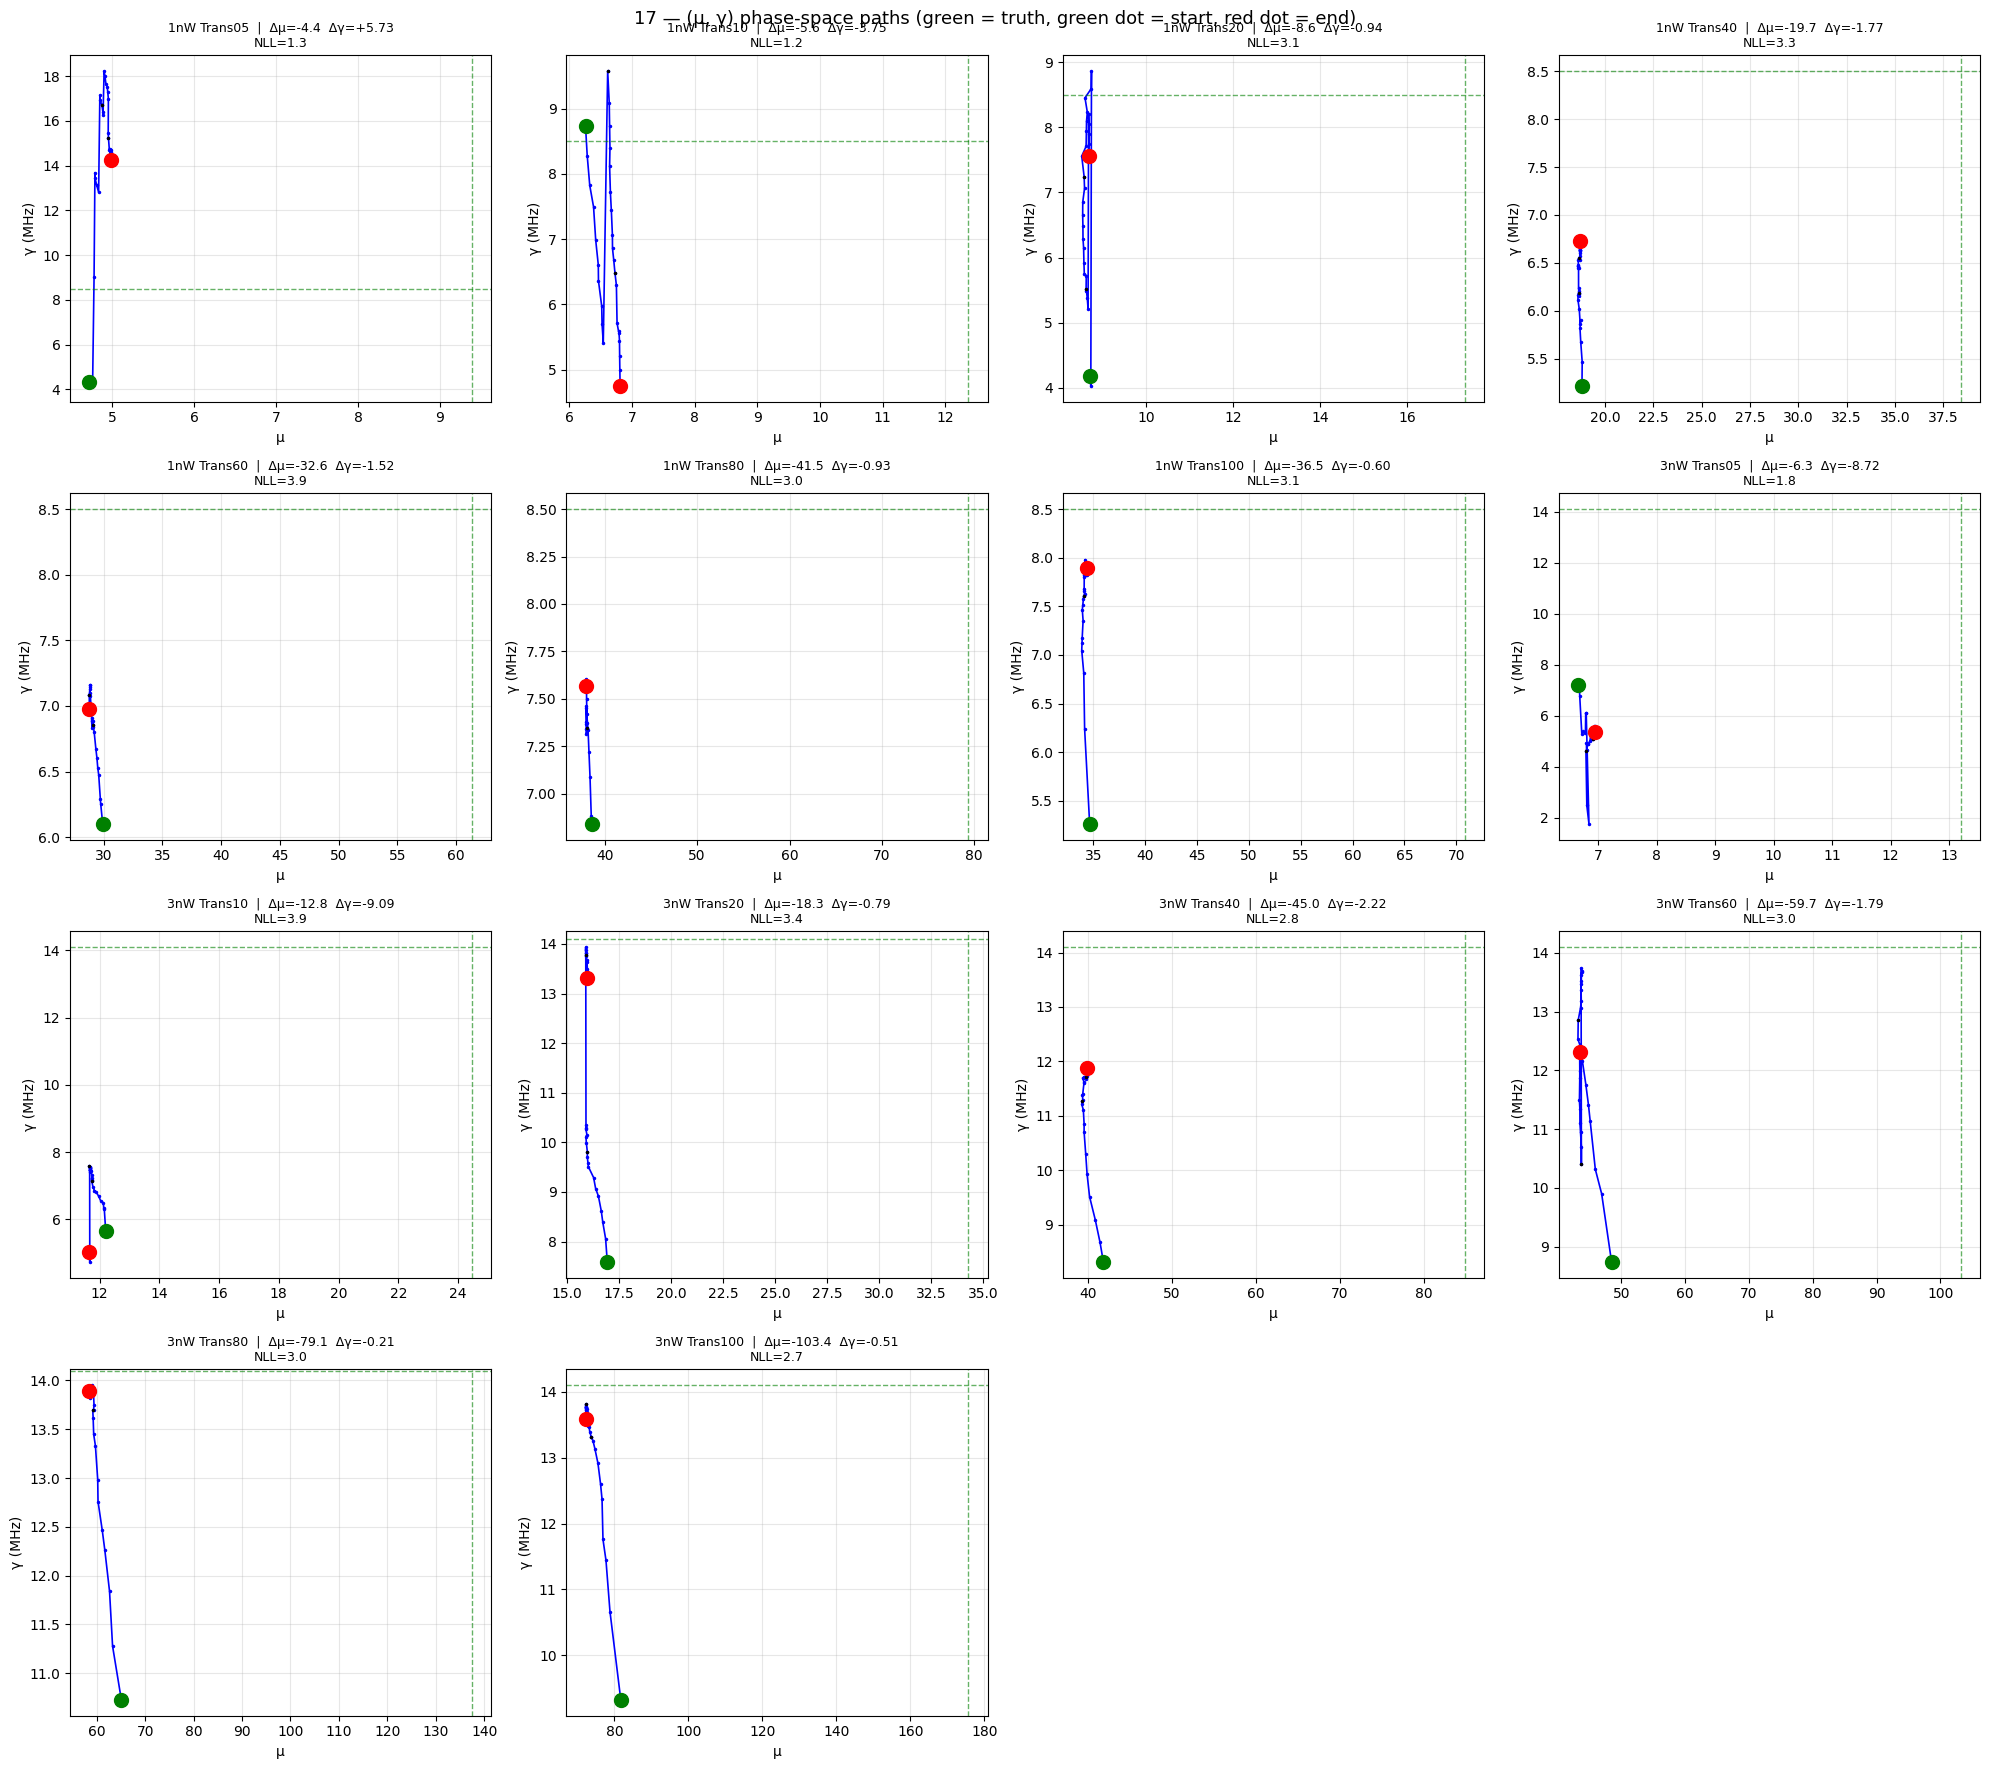

In [8]:
# ============================================================
# FIG 1 — optimization paths in (μ, γ) phase space (quick diagnosis)
# ============================================================
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
for idx, r in enumerate(results):
    ax = axes[idx // 4][idx % 4]
    hs = r['history']
    mus = [h['mu'] for h in hs]
    gams = [h['gamma'] for h in hs]
    ax.plot(mus, gams, 'b.-', lw=1.2, ms=3)
    ax.plot(mus[::10], gams[::10], 'k.', ms=3)                    # every 10th step
    ax.plot(mus[0], gams[0], 'go', ms=10, label='start')
    ax.plot(mus[-1], gams[-1], 'ro', ms=10, label='end')
    ax.axvline(r['mu_true'], color='g', ls='--', lw=1, alpha=0.6)
    ax.axhline(r['gamma_true'], color='g', ls='--', lw=1, alpha=0.6)
    ax.set_title(f"{r['exp']}  |  Δμ={r['mu_final']-r['mu_true']:+.1f}  Δγ={r['gamma_final']-r['gamma_true']:+.2f}\nNLL={r['nll_final']:.1f}", fontsize=9)
    ax.set_xlabel('μ'); ax.set_ylabel('γ (MHz)')
    ax.grid(alpha=0.3)
for idx in range(len(results), 16):
    axes[idx // 4][idx % 4].axis('off')
plt.suptitle('17 — (μ, γ) phase-space paths (green = truth, green dot = start, red dot = end)', fontsize=13)
plt.tight_layout()
plt.show()

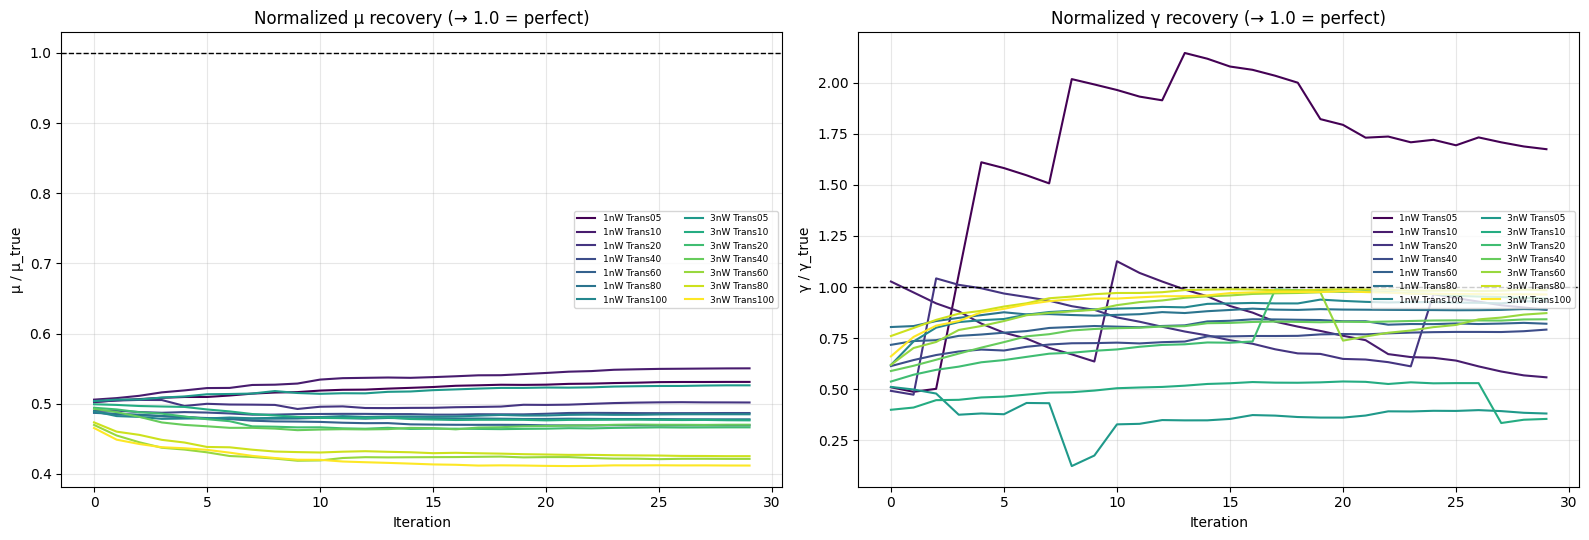

In [9]:
# ============================================================
# FIG 2 — normalized trajectories overlay (→ 1.0 = perfect recovery)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
for r, c in zip(results, colors):
    hs = r['history']
    steps = [h['step'] for h in hs]
    axes[0].plot(steps, [h['mu'] / r['mu_true'] for h in hs], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(steps, [h['gamma'] / r['gamma_true'] for h in hs], color=c, lw=1.5, label=r['exp'])
for ax, ylab in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set_xlabel('Iteration'); ax.set_ylabel(ylab)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout()
plt.show()

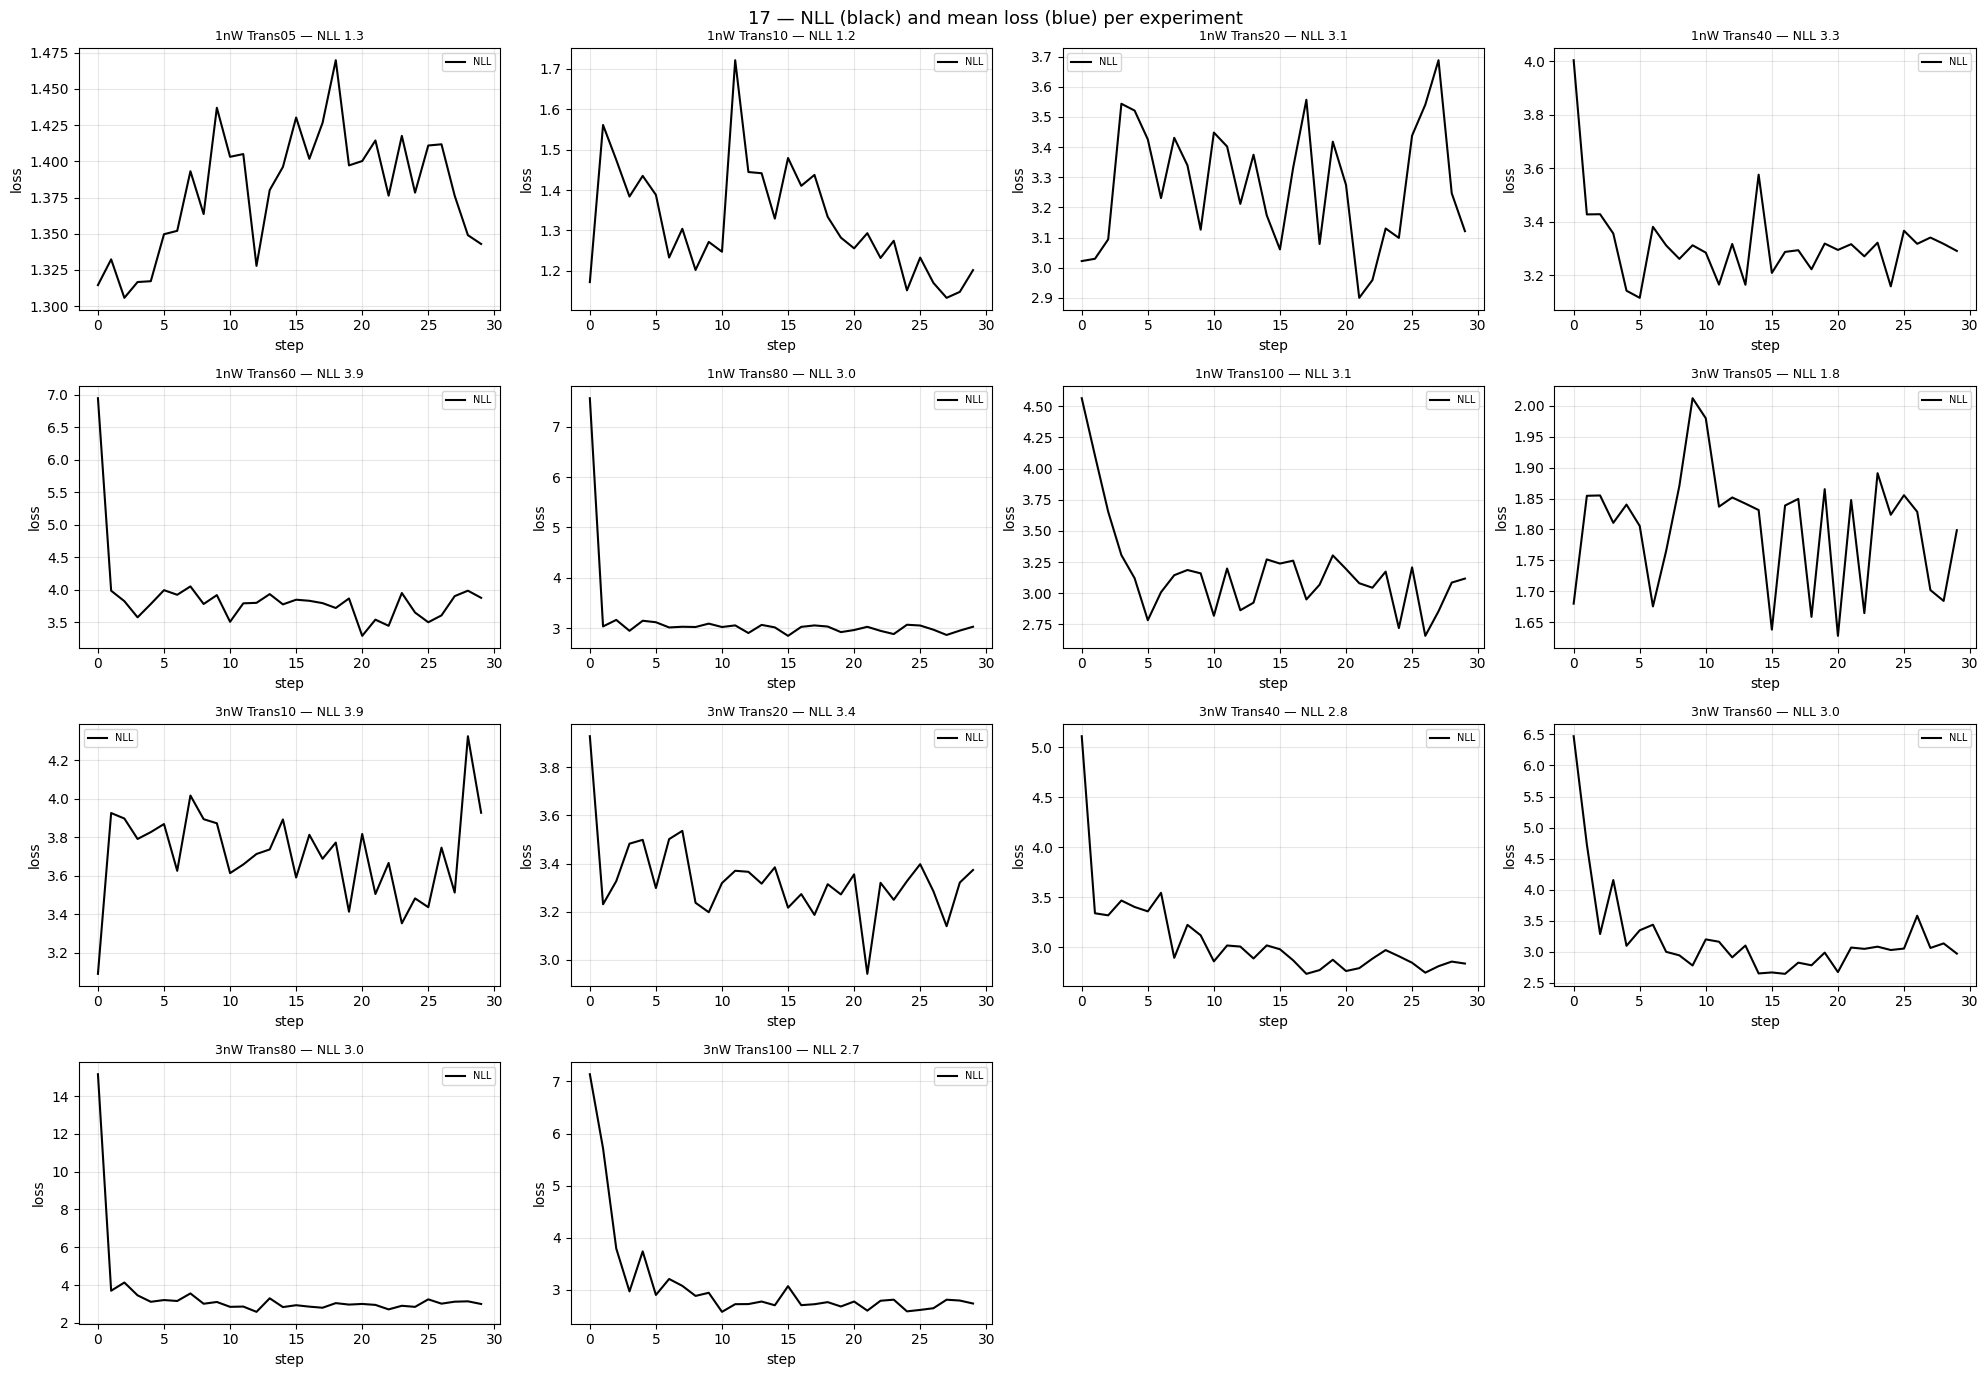

In [10]:
# ============================================================
# FIG 3 — NLL per experiment (dead kernel shows up as high/flat NLL)
# ============================================================
fig, axes = plt.subplots(4, 4, figsize=(20, 14))
for idx, r in enumerate(results):
    ax = axes[idx // 4][idx % 4]
    hs = r['history']
    ax.plot([h['step'] for h in hs], [h['nll'] for h in hs], 'k-', lw=1.5, label='NLL')
    if LAMBDA_MEAN > 0:
        ax.plot([h['step'] for h in hs], [h['mean_loss'] for h in hs], 'b-', lw=1.0, alpha=0.7, label='mean loss')
    ax.set_title(f"{r['exp']} — NLL {r['nll_final']:.1f}", fontsize=9)
    ax.set_xlabel('step'); ax.set_ylabel('loss')
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
for idx in range(len(results), 16):
    axes[idx // 4][idx % 4].axis('off')
plt.suptitle('17 — NLL (black) and mean loss (blue) per experiment', fontsize=13)
plt.tight_layout()
plt.show()

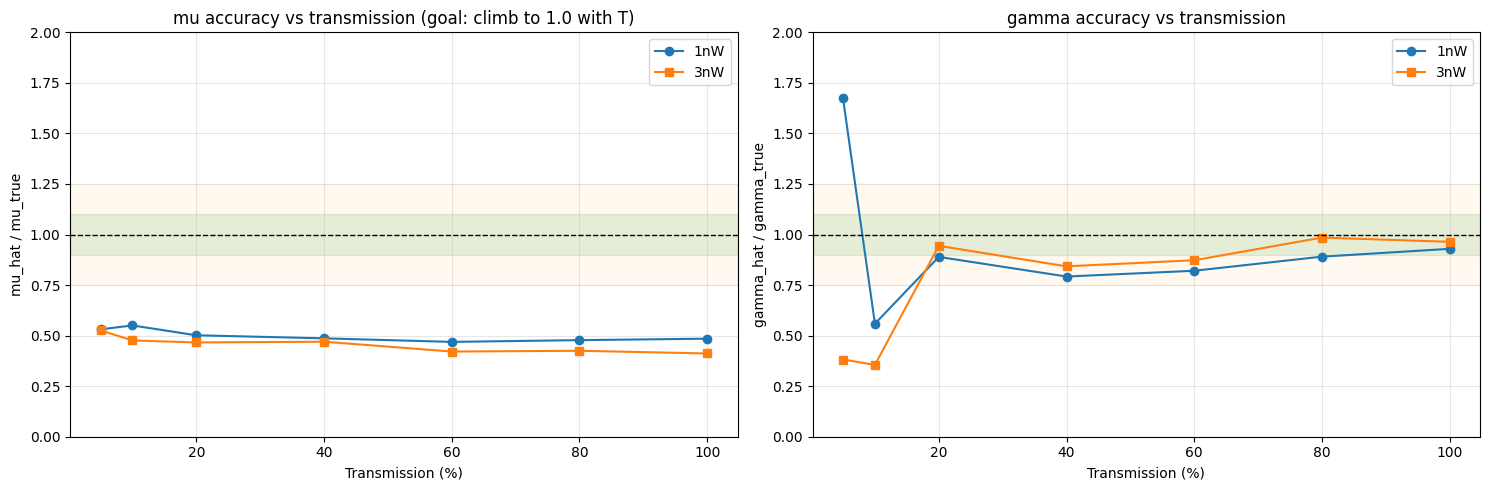

graded goal check (mu_hat/mu_true, gamma_hat/gamma_true by transmission):
    T  mu_ratio(1nW)  mu_ratio(3nW)  g_ratio(1nW)  g_ratio(3nW)
    5          0.531          0.526         1.674         0.382
   10           0.55          0.476         0.559         0.355
   20          0.502          0.466         0.889         0.944
   40          0.487           0.47         0.792         0.843
   60          0.469          0.421         0.821         0.873
   80          0.478          0.425         0.891         0.985
  100          0.485          0.412         0.929         0.964


In [11]:
# ============================================================
# FIG 4 — ACCURACY vs TRANSMISSION (goal figure): mu and gamma ratios vs T
# goal: ratios should climb toward 1.0 as T increases; loose at low T.
# ============================================================
pows = ['1nW', '3nW']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = [r for r in results if r['power'] == p]
        xs = [Tmap[r['exp']] for r in rs]
        ys = [r['mu_final']/r['mu_true'] for r in rs] if key == 'mu' else [r['gamma_final']/r['gamma_true'] for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.axhspan(0.9, 1.1, color='green', alpha=0.10)
    ax.axhspan(0.75, 1.25, color='orange', alpha=0.06)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true')
    ax.set_ylim(0, 2.0); ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('mu accuracy vs transmission (goal: climb to 1.0 with T)')
axes[1].set_title('gamma accuracy vs transmission')
plt.tight_layout(); plt.show()

# graded-goal check (SERIES_STATE.md): delta ratio shrinks with T
print('graded goal check (mu_hat/mu_true, gamma_hat/gamma_true by transmission):')
print(f"{'T':>5} {'mu_ratio(1nW)':>14} {'mu_ratio(3nW)':>14} {'g_ratio(1nW)':>13} {'g_ratio(3nW)':>13}")
for T in sorted(set(Tmap.values())):
    row = [T]
    for p in pows:
        rs = [r for r in results if r['power'] == p and Tmap[r['exp']] == T]
        row.append(round(rs[0]['mu_final']/rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in pows:
        rs = [r for r in results if r['power'] == p and Tmap[r['exp']] == T]
        row.append(round(rs[0]['gamma_final']/rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{row[0]:>5} {row[1]:>14} {row[2]:>14} {row[3]:>13} {row[4]:>13}")


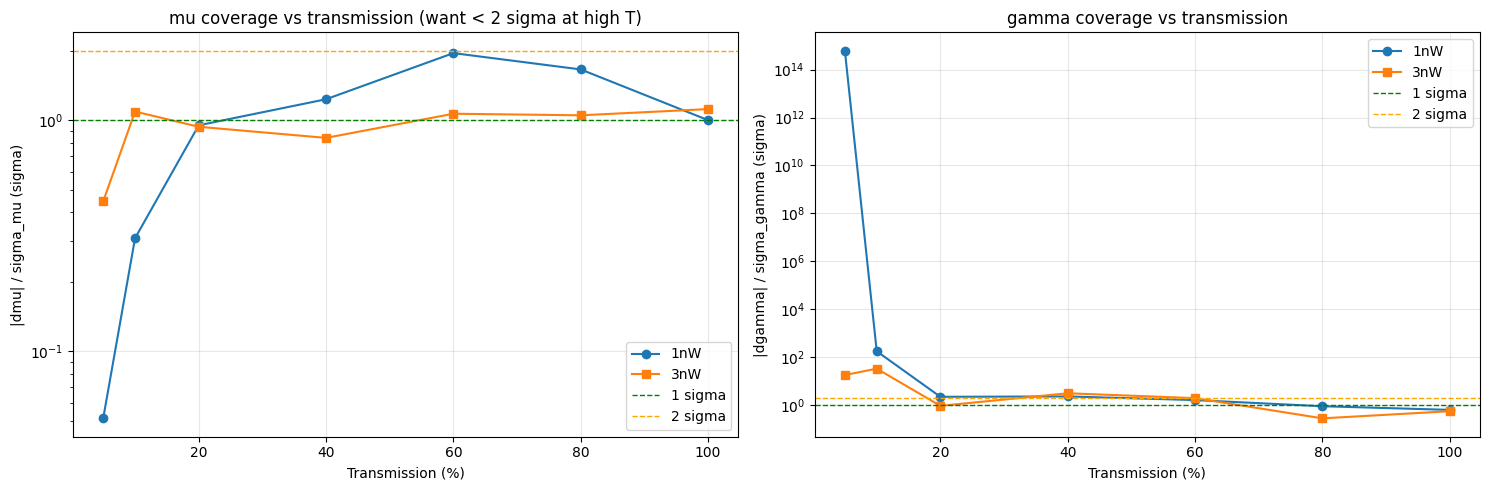

In [12]:
# ============================================================
# FIG 5 — COVERAGE vs TRANSMISSION: |dmu|/sigma_mu and |dgamma|/sigma_gamma vs T
# (the "reasonable uncertainty" check; bands at 1-sigma / 2-sigma)
# ============================================================
fr = {f['exp']: f for f in fisher_rows}
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = [r for r in results if r['power'] == p]
        xs = [Tmap[r['exp']] for r in rs]
        if key == 'mu':
            ys = [abs(fr[r['exp']]['mu_f']-fr[r['exp']]['mu_true'])/fr[r['exp']]['std_mu'] for r in rs]
        else:
            ys = [abs(fr[r['exp']]['gamma_f']-fr[r['exp']]['gamma_true'])/fr[r['exp']]['std_gamma'] for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1, color='green', ls='--', lw=1, label='1 sigma')
    ax.axhline(2, color='orange', ls='--', lw=1, label='2 sigma')
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'|d{key}| / sigma_{key} (sigma)')
    ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('mu coverage vs transmission (want < 2 sigma at high T)')
axes[1].set_title('gamma coverage vs transmission')
plt.tight_layout(); plt.show()


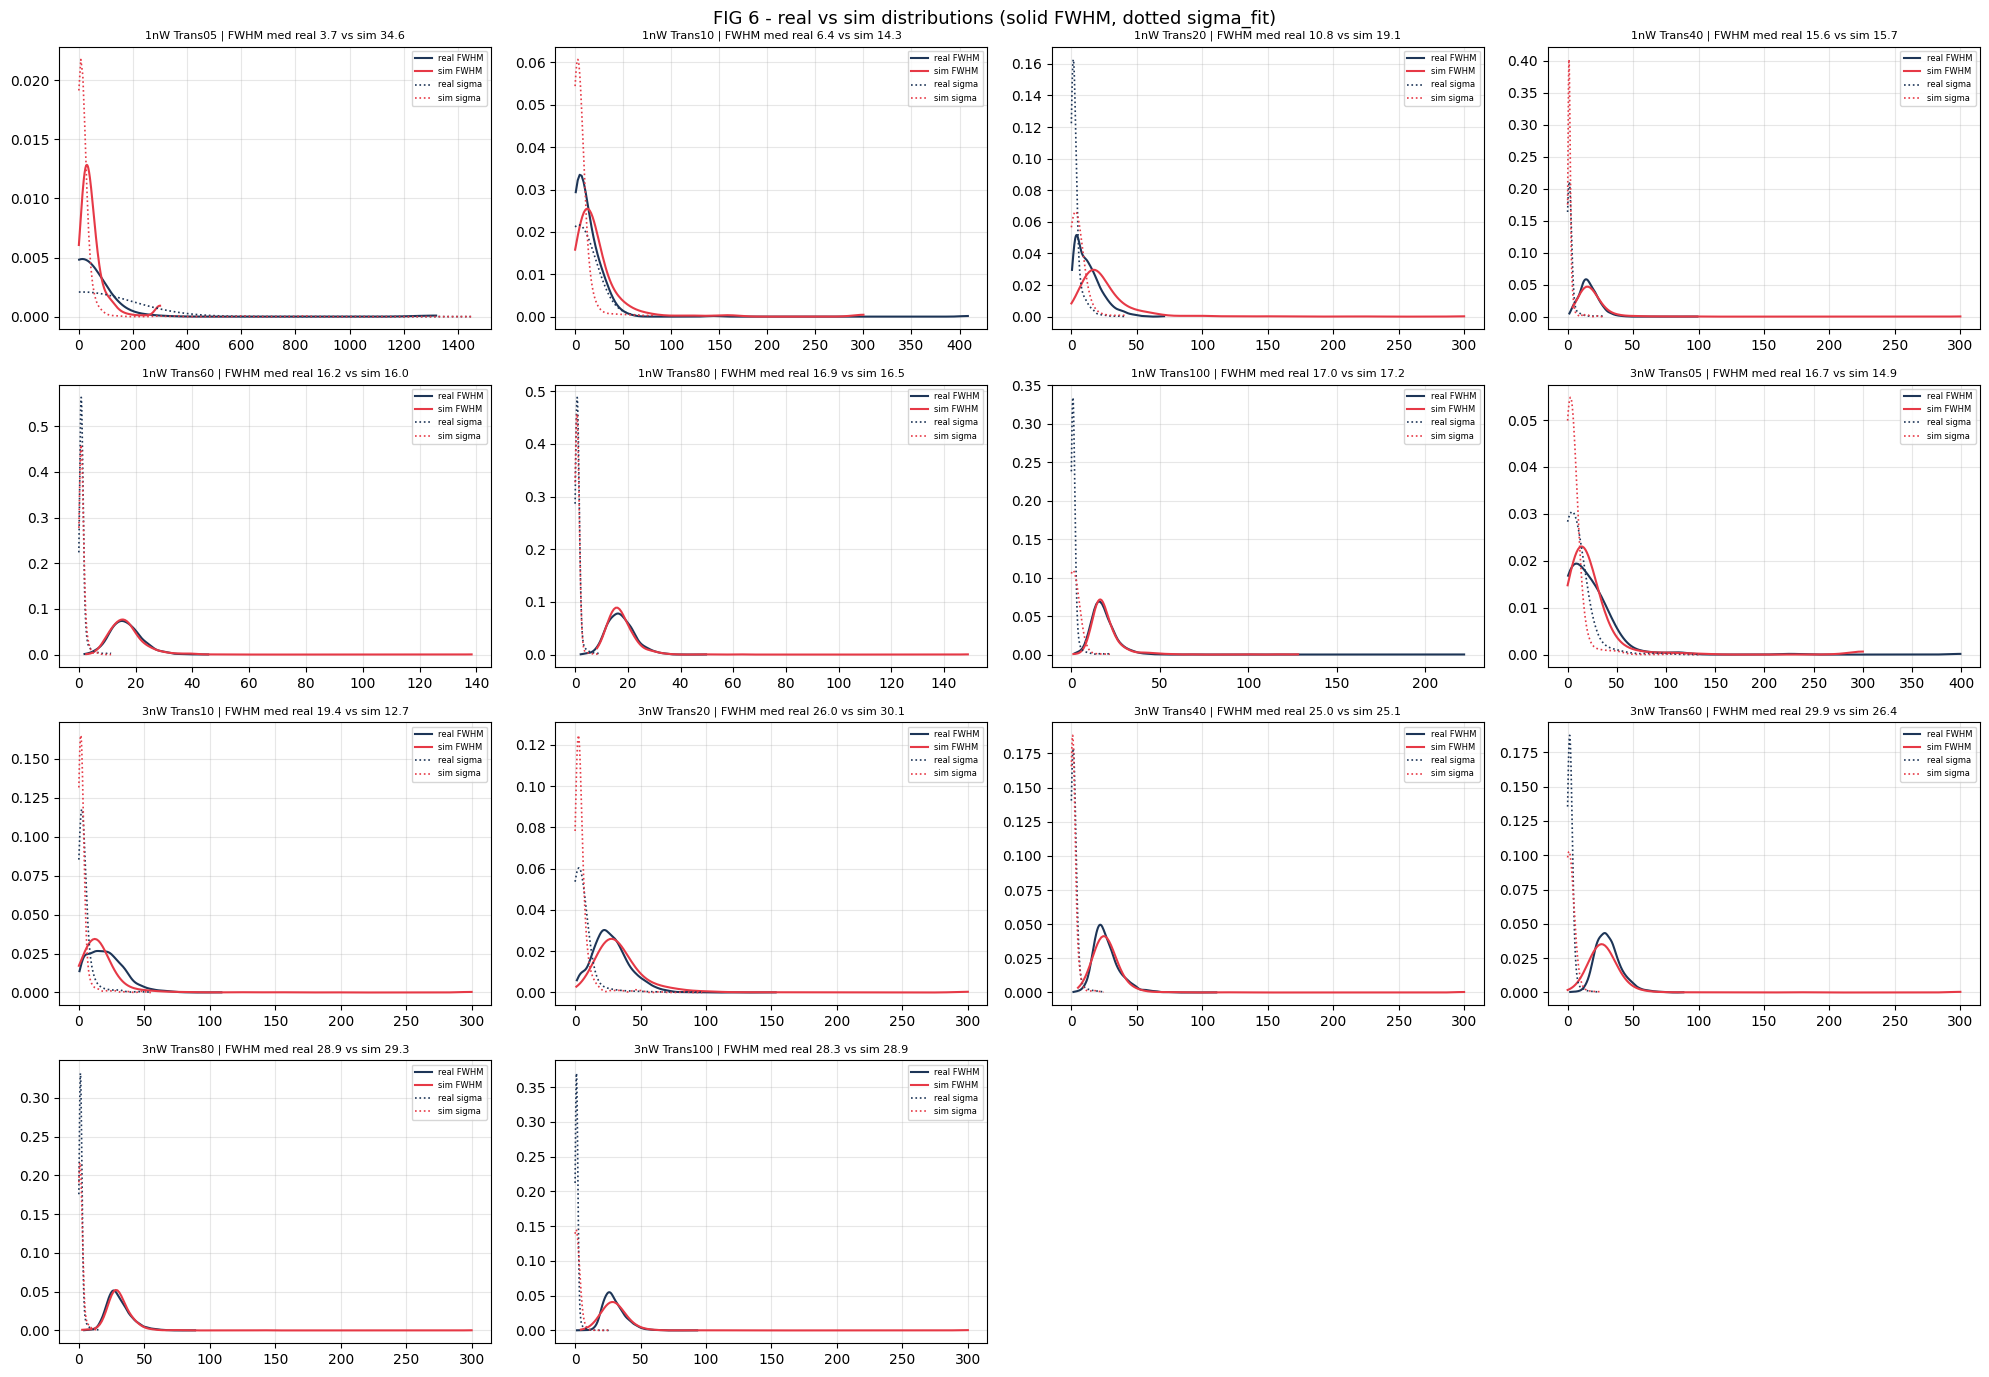

In [13]:
# ============================================================
# FIG 6 — DISTRIBUTION MATCH: real target vs fitted-point sim (FWHM + sigma_fit)
# ============================================================
from scipy.stats import gaussian_kde
fig, axes = plt.subplots(4, 4, figsize=(20, 14))
for idx, r in enumerate(results):
    ax = axes[idx // 4][idx % 4]
    tf = r['target_f'].numpy(); ts = r['target_s'].numpy()
    sf, ss, sn = FIT[r['exp']]; sf = sf.numpy(); ss = ss.numpy()
    for arr, c, lab in [(tf, '#1d3557', 'real'), (sf, '#e63946', 'sim')]:
        if arr.std() > 0:
            xs = np.linspace(arr.min(), arr.max(), 200)
            ax.plot(xs, gaussian_kde(arr)(xs), color=c, lw=1.5, label=f'{lab} FWHM')
    if ts.std() > 0 and ss.std() > 0:
        xs2 = np.linspace(0, max(np.percentile(ts, 99), np.percentile(ss, 99)), 200)
        ax.plot(xs2, gaussian_kde(ts)(xs2), color='#1d3557', ls=':', lw=1.2, label='real sigma')
        ax.plot(xs2, gaussian_kde(ss)(xs2), color='#e63946', ls=':', lw=1.2, label='sim sigma')
    ax.set_title(f"{r['exp']} | FWHM med real {np.median(tf):.1f} vs sim {np.median(sf):.1f}", fontsize=8)
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
for idx in range(len(results), 16):
    axes[idx // 4][idx % 4].axis('off')
plt.suptitle('FIG 6 - real vs sim distributions (solid FWHM, dotted sigma_fit)', fontsize=13)
plt.tight_layout(); plt.show()


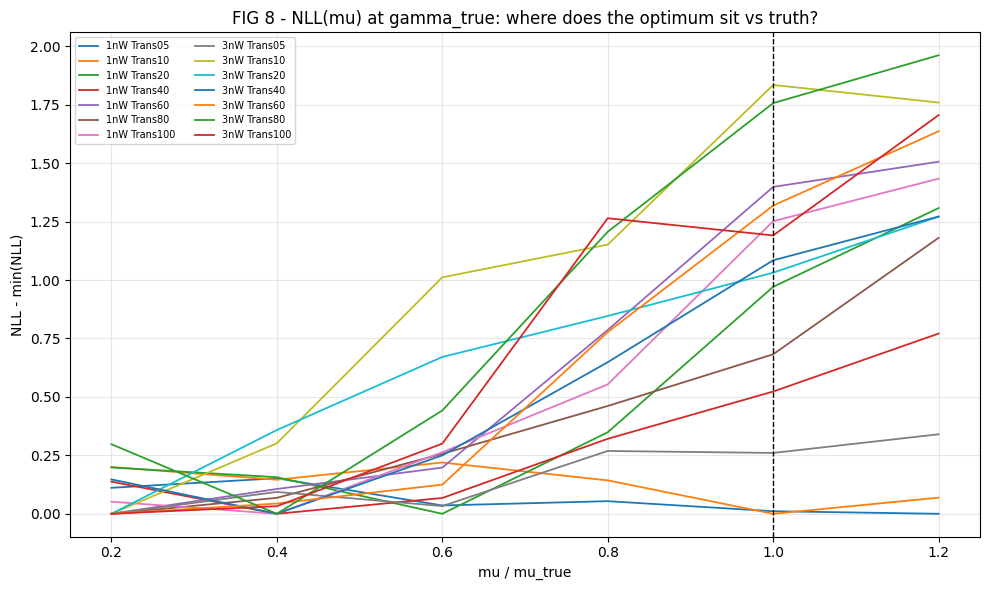

In [14]:
# ============================================================
# FIG 8 — NLL(mu) at fixed gamma_true (mu-attractor diagnostic)
# If the minimum sits at mu/mu_true < 1, the model's optimum is biased vs truth.
# ============================================================
ratios = np.linspace(0.2, 1.2, 6)
fig, ax = plt.subplots(figsize=(10, 6))
for r in results:
    mu_t, g_t, sp, lam = r['mu_true'], r['gamma_true'], r['sigma_prop'], r['lam']
    nlls = []
    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
        for ratio in ratios:
            rng = np.random.default_rng(SEED + 999)
            tasks = []
            for _ in range(N_RUNS):
                u, b_, n = draw_fixed_noise(ratio*mu_t, sp, lam, rng)
                tasks.append((g_t, u.numpy(), b_.numpy()))
            res = _parallel_map(pool, tasks)
            ft = torch.tensor([x[0] for x in res], dtype=torch.float32)
            si_t = torch.tensor([x[1] for x in res], dtype=torch.float32)
            d_f = r['target_f'][:, None] - ft[None, :]
            d_s = r['target_s'][:, None] - si_t[None, :]
            W = torch.exp(-0.5 * (d_f / r['H_F']) ** 2 - 0.5 * (d_s / r['H_S']) ** 2)
            logp = torch.log((W.sum(dim=1) / len(ft)).clamp_min(1e-30))
            nlls.append(float(-logp.mean()))
    nlls = np.array(nlls) - np.min(nlls)
    ax.plot(ratios, nlls, lw=1.3, label=r['exp'])
ax.set_xlabel('mu / mu_true'); ax.set_ylabel('NLL - min(NLL)')
ax.axvline(1.0, color='k', ls='--', lw=1)
ax.set_title('FIG 8 - NLL(mu) at gamma_true: where does the optimum sit vs truth?')
ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


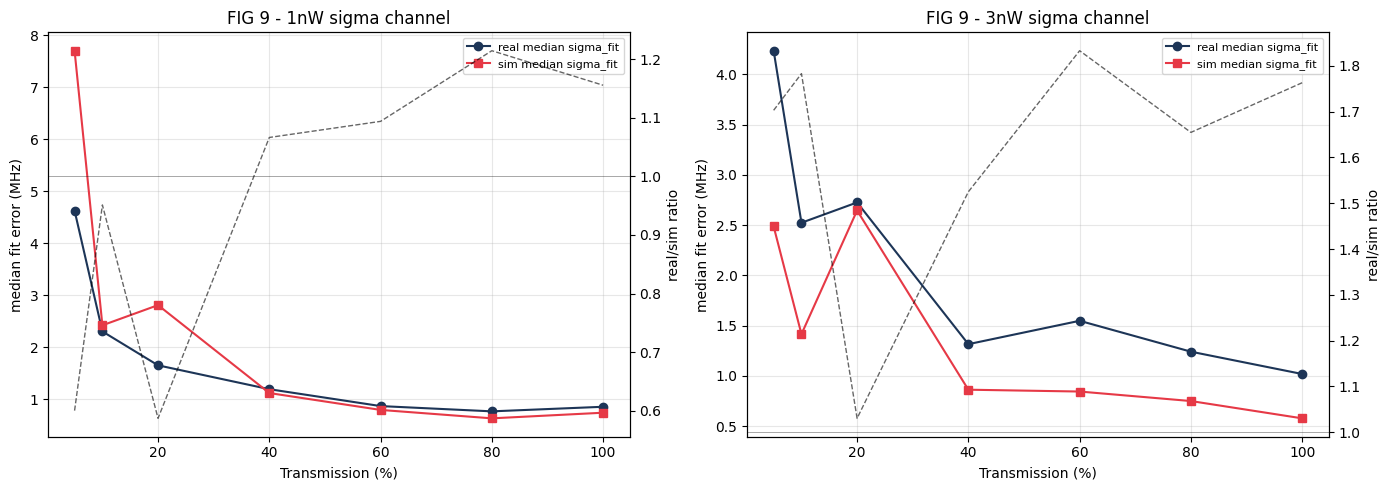

In [15]:
# ============================================================
# FIG 9 — SIGMA-CHANNEL AUTOPSY: median fit error (real vs sim) vs transmission (FM#8)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, p in zip(axes, pows):
    rs = [r for r in results if r['power'] == p]
    rs = sorted(rs, key=lambda r: Tmap[r['exp']])
    xs = [Tmap[r['exp']] for r in rs]
    real_med = [float(np.median(r['target_s'].numpy())) for r in rs]
    sim_med = [float(np.median(FIT[r['exp']][1].numpy())) for r in rs]
    ax.plot(xs, real_med, 'o-', label='real median sigma_fit', color='#1d3557')
    ax.plot(xs, sim_med, 's-', label='sim median sigma_fit', color='#e63946')
    ax2 = ax.twinx()
    ax2.plot(xs, [rr/s if s > 0 else np.nan for rr, s in zip(real_med, sim_med)], 'k--', lw=1, alpha=0.6, label='ratio real/sim')
    ax2.set_ylabel('real/sim ratio'); ax2.axhline(1, color='k', lw=0.6, alpha=0.4)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel('median fit error (MHz)')
    ax.set_title(f'FIG 9 - {p} sigma channel'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


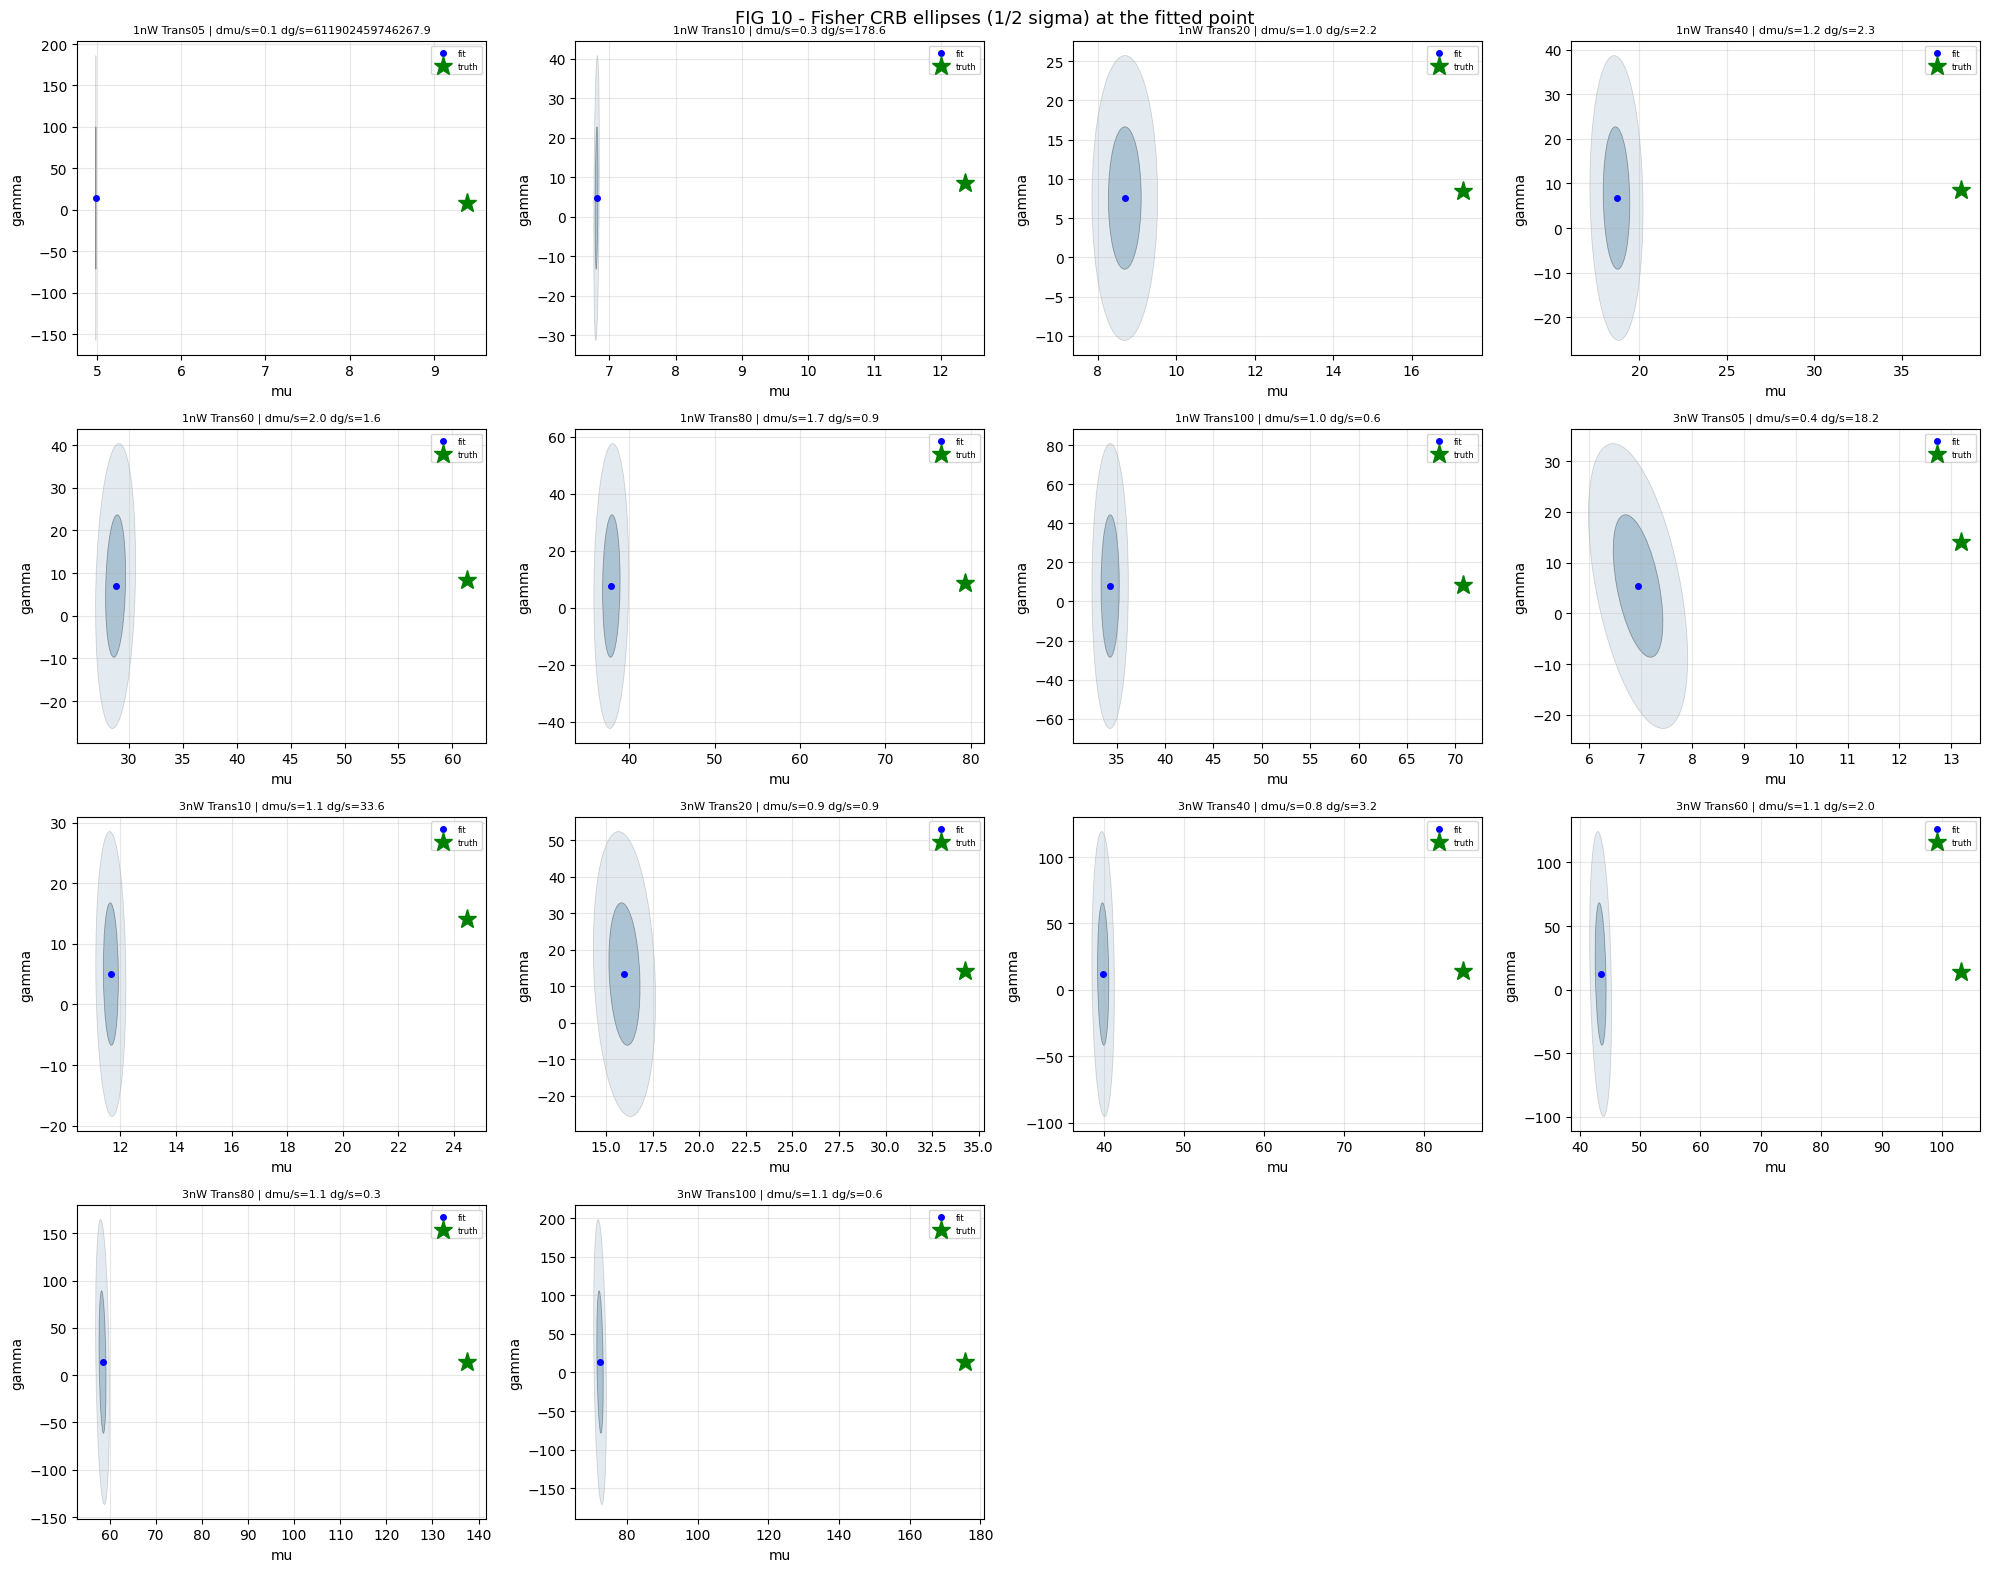

In [16]:
# ============================================================
# FIG 10 — FISHER ELLIPSES (1-sigma) in (mu, gamma) at the fitted point
# ============================================================
from matplotlib.patches import Ellipse
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for idx, f in enumerate(fisher_rows):
    ax = axes[idx // 4][idx % 4]
    cov = np.array([[f['std_mu']**2, f['corr']*f['std_mu']*f['std_gamma']],
                    [f['corr']*f['std_mu']*f['std_gamma'], f['std_gamma']**2]])
    for nsig, al in [(1, 0.35), (2, 0.15)]:
        lam_, vec = np.linalg.eigh(cov * nsig**2)
        ang = np.degrees(np.arctan2(vec[1, -1], vec[0, -1]))
        w, h = 2*np.sqrt(lam_)
        ax.add_patch(Ellipse((f['mu_f'], f['gamma_f']), w, h, angle=ang,
                             facecolor='#457b9d', edgecolor='k', alpha=al, lw=0.6))
    ax.plot(f['mu_f'], f['gamma_f'], 'b.', ms=8, label='fit')
    ax.plot(f['mu_true'], f['gamma_true'], 'g*', ms=14, label='truth')
    ax.set_title(f"{f['exp']} | dmu/s={abs(f['mu_f']-f['mu_true'])/f['std_mu']:.1f} "
                 f"dg/s={abs(f['gamma_f']-f['gamma_true'])/f['std_gamma']:.1f}", fontsize=8)
    ax.set_xlabel('mu'); ax.set_ylabel('gamma'); ax.grid(alpha=0.3); ax.legend(fontsize=6)
for idx in range(len(fisher_rows), 16):
    axes[idx // 4][idx % 4].axis('off')
plt.suptitle('FIG 10 - Fisher CRB ellipses (1/2 sigma) at the fitted point', fontsize=13)
plt.tight_layout(); plt.show()


In [17]:
# ============================================================
# RESULTS TABLE + MSE / STE
# ============================================================
print(f"{'exp':<12} {'μ_true':>7} {'μ_final':>8} {'Δμ':>7} | {'γ_true':>6} {'γ_final':>8} {'Δγ':>7} | {'NLL':>6}")
print('-' * 78)
for r in results:
    print(f"{r['exp']:<12} {r['mu_true']:>7.2f} {r['mu_final']:>8.2f} {r['mu_final']-r['mu_true']:>+7.2f} | "
          f"{r['gamma_true']:>6.1f} {r['gamma_final']:>8.2f} {r['gamma_final']-r['gamma_true']:>+7.2f} | {r['nll_final']:>6.2f}")

def mse_stats(err):
    err = np.asarray(err, dtype=float)
    sq = err ** 2
    mse = sq.mean()
    ste = sq.std(ddof=1) / math.sqrt(len(sq))   # standard error of the MSE estimate
    return mse, ste, math.sqrt(mse), err.mean()

dmu = np.array([r['mu_final'] - r['mu_true'] for r in results])
dg = np.array([r['gamma_final'] - r['gamma_true'] for r in results])
rdmu = dmu / np.array([r['mu_true'] for r in results])
rdg = dg / np.array([r['gamma_true'] for r in results])

print('\n=== MSE / STE over the %d experiments ===' % len(results))
for label, err, rel in [('μ (photons)', dmu, rdmu), ('γ (MHz)', dg, rdg)]:
    mse, ste, rmse, bias = mse_stats(err)
    _, _, rmse_rel, bias_rel = mse_stats(rel)
    print(f'{label:>12}: bias={bias:+.3f} | MSE={mse:.4f} ± {ste:.4f} (STE) | RMSE={rmse:.3f} | '
          f'rel-RMSE={rmse_rel*100:.1f}% | rel-bias={bias_rel*100:+.1f}%')

for p in ['1nW', '3nW']:
    sel = [i for i, r in enumerate(results) if r['power'] == p]
    if not sel:
        continue
    print(f'\n--- {p} ({len(sel)} experiments) ---')
    for label, err, rel in [('μ (photons)', dmu[sel], rdmu[sel]), ('γ (MHz)', dg[sel], rdg[sel])]:
        mse, ste, rmse, bias = mse_stats(err)
        _, _, rmse_rel, bias_rel = mse_stats(rel)
        print(f'  {label:>12}: bias={bias:+.3f} | MSE={mse:.4f} ± {ste:.4f} (STE) | RMSE={rmse:.3f} | '
              f'rel-RMSE={rmse_rel*100:.1f}% | rel-bias={bias_rel*100:+.1f}%')
# jump diagnostics: max single-step γ change per experiment (the "big jumps" from 17a/17d/18b)
print()
print(f"{'exp':<12} {'max|Δγ|/step':>13}")
for r in results:
    hs = r['history']
    jumps = [abs(hs[i+1]['gamma'] - hs[i]['gamma']) for i in range(len(hs)-1)]
    print(f"{r['exp']:<12} {max(jumps) if jumps else 0:>13.2f}")

exp           μ_true  μ_final      Δμ | γ_true  γ_final      Δγ |    NLL
------------------------------------------------------------------------------
1nW Trans05     9.39     4.99   -4.41 |    8.5    14.23   +5.73 |   1.34
1nW Trans10    12.37     6.81   -5.56 |    8.5     4.75   -3.75 |   1.20
1nW Trans20    17.32     8.69   -8.63 |    8.5     7.56   -0.94 |   3.12
1nW Trans40    38.41    18.69  -19.72 |    8.5     6.73   -1.77 |   3.29
1nW Trans60    61.37    28.78  -32.59 |    8.5     6.98   -1.52 |   3.88
1nW Trans80    79.36    37.91  -41.45 |    8.5     7.57   -0.93 |   3.03
1nW Trans100   70.82    34.33  -36.48 |    8.5     7.90   -0.60 |   3.12
3nW Trans05    13.20     6.95   -6.26 |   14.1     5.38   -8.72 |   1.80
3nW Trans10    24.48    11.66  -12.82 |   14.1     5.01   -9.09 |   3.93
3nW Trans20    34.28    15.98  -18.30 |   14.1    13.31   -0.79 |   3.37
3nW Trans40    84.89    39.89  -45.00 |   14.1    11.88   -2.22 |   2.84
3nW Trans60   103.20    43.47  -59.73 |   14.

In [18]:
# ============================================================
# EXPORT -> data/processed/20a_history.json  (series-20 convention)
# ============================================================
import json as _json
NB_ID = '20a'
def _to_py(x):
    if isinstance(x, dict): return {k: _to_py(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)): return [_to_py(v) for v in x]
    if hasattr(x, 'tolist'): return x.tolist()
    if isinstance(x, (np.floating, np.integer)): return x.item()
    return x
hist_out = dict(
    notebook=NB_ID, n_runs=N_RUNS, n_iter=N_ITER, m_final=M_FINAL, smoke=bool(SMOKE),
    config=dict(LR_MU=LR_MU, LR_GAMMA=LR_GAMMA, SIGMA_REF=SIGMA_REF, GAMMA_SCALE=GAMMA_SCALE,
                H_REF=H_REF, CLIP=CLIP, LAMBDA_MEAN=LAMBDA_MEAN, H_S_MIN=H_S_MIN, SEED=SEED),
    results=[dict(exp=r['exp'], power=r['power'], mu_true=r['mu_true'], gamma_true=r['gamma_true'],
                  sigma_prop=r['sigma_prop'], lam=r['lam'], n_target=r['n_target'],
                  mu_final=r['mu_final'], gamma_final=r['gamma_final'], nll_final=r['nll_final'],
                  H_F=r['H_F'], H_S=r['H_S'], t_elapsed=r['t_elapsed'], history=r['history'],
                  target_f=r['target_f'].tolist(), target_s=r['target_s'].tolist())
             for r in results],
    fisher_rows=[_to_py(f) for f in fisher_rows],
)
_out = '/tmp/_smoke_history.json' if SMOKE else f'data/processed/{NB_ID}_history.json'
os.makedirs(os.path.dirname(_out) or '.', exist_ok=True)
with open(_out, 'w') as fh:
    _json.dump(hist_out, fh)
print('wrote', _out)


wrote data/processed/20a_history.json
